In [1]:
import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']

df_cols_to_drop = ['campaign_id']

df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)
df.drop(columns=df_cols_to_drop, inplace=True)

Loaded dataframe from .h5 file: ./data/dataframe_cache/5G_data_2023.h5


In [2]:
from scripts.data_filter import filter_dataframe

df = filter_dataframe(
    df=df,
    operators=[10],
    include_columns=['pci', 'beam_index', 'nr_arfcn', 'operator_id', 'sinr']
)

In [3]:
from scripts.weighted_coverage import run_weighted_coverage
from scripts.utils import extract_unique_npcis, RF_PARAM_5G
import pandas as pd

# Parameters
n_runs = 10
max_k_wknn = 3
n_clusters = 20
rf_params = [RF_PARAM_5G.SINR]
clustering_params = [RF_PARAM_5G.SINR]
operator_choice = np.array([10])
unique_npcis = extract_unique_npcis(df['measurements_matrix'])

print(f"""
Running weighted coverage

🧪 Experiment setup 🧪 
🔢 max k-value for wKNN = {max_k_wknn}
🛜 RF PARAM {str(rf_params)}
📶 Operator choice {operator_choice}
🔁 Number of runs {n_runs}|
_________________________________
""")

k_range = range(1, max_k_wknn + 1)
errors_dict = {c: [] for c in k_range}  # Store the errors


def run_experiment(k, random_seed):
    _, errors, _, _ = run_weighted_coverage(
        df, rf_params, [], k, unique_npcis, random_seed, 0
    )
    return errors.mean()


k = 2
# for k in k_range:
for i in range(n_runs):
    print(f"\r🔄 Running for k={k} ({i + 1}/{n_runs} runs)", end="")
    random = random_seeds[i]

    _, errors, complexity, runtime = run_weighted_coverage(
        df, rf_params, clustering_params, k, unique_npcis, random, n_clusters
    )
    errors_dict[k].append(errors.mean())

    print(f"\r✅ {k} completed                                           ")

# errors_df = pd.DataFrame(errors_dict)
errors_df = pd.DataFrame(errors_dict[2])



Running weighted coverage

🧪 Experiment setup 🧪 
🔢 max k-value for wKNN = 3
🛜 RF PARAM [<RF_PARAM_5G.SINR: 'sinr'>]
📶 Operator choice [10]
🔁 Number of runs 10|
_________________________________

🔄 Running for k=2 (1/10 runs)Processing test points...
TP DataFrame size: 1.48 MB
RP DataFrame size: 3.34 MB
Matrix RP (1848, 295, 1)
Matrix TP (813, 295, 1)
Weights (813, 1848)
Processing test points...
TP DataFrame size: 2.05 MB
RP DataFrame size: 4.72 MB
Matrix RP (2232, 295, 1)
Matrix TP (967, 295, 1)
Weights (967, 2232)
Processing test points...
TP DataFrame size: 0.98 MB
RP DataFrame size: 2.06 MB
Matrix RP (1149, 295, 1)
Matrix TP (545, 295, 1)
Weights (545, 1149)
Processing test points...
TP DataFrame size: 0.52 MB
RP DataFrame size: 1.13 MB
Matrix RP (641, 295, 1)
Matrix TP (289, 295, 1)
Weights (289, 641)
Processing test points...
TP DataFrame size: 0.99 MB
RP DataFrame size: 2.08 MB
Matrix RP (1082, 295, 1)
Matrix TP (514, 295, 1)
Weights (514, 1082)
Processing test points...
TP Dat

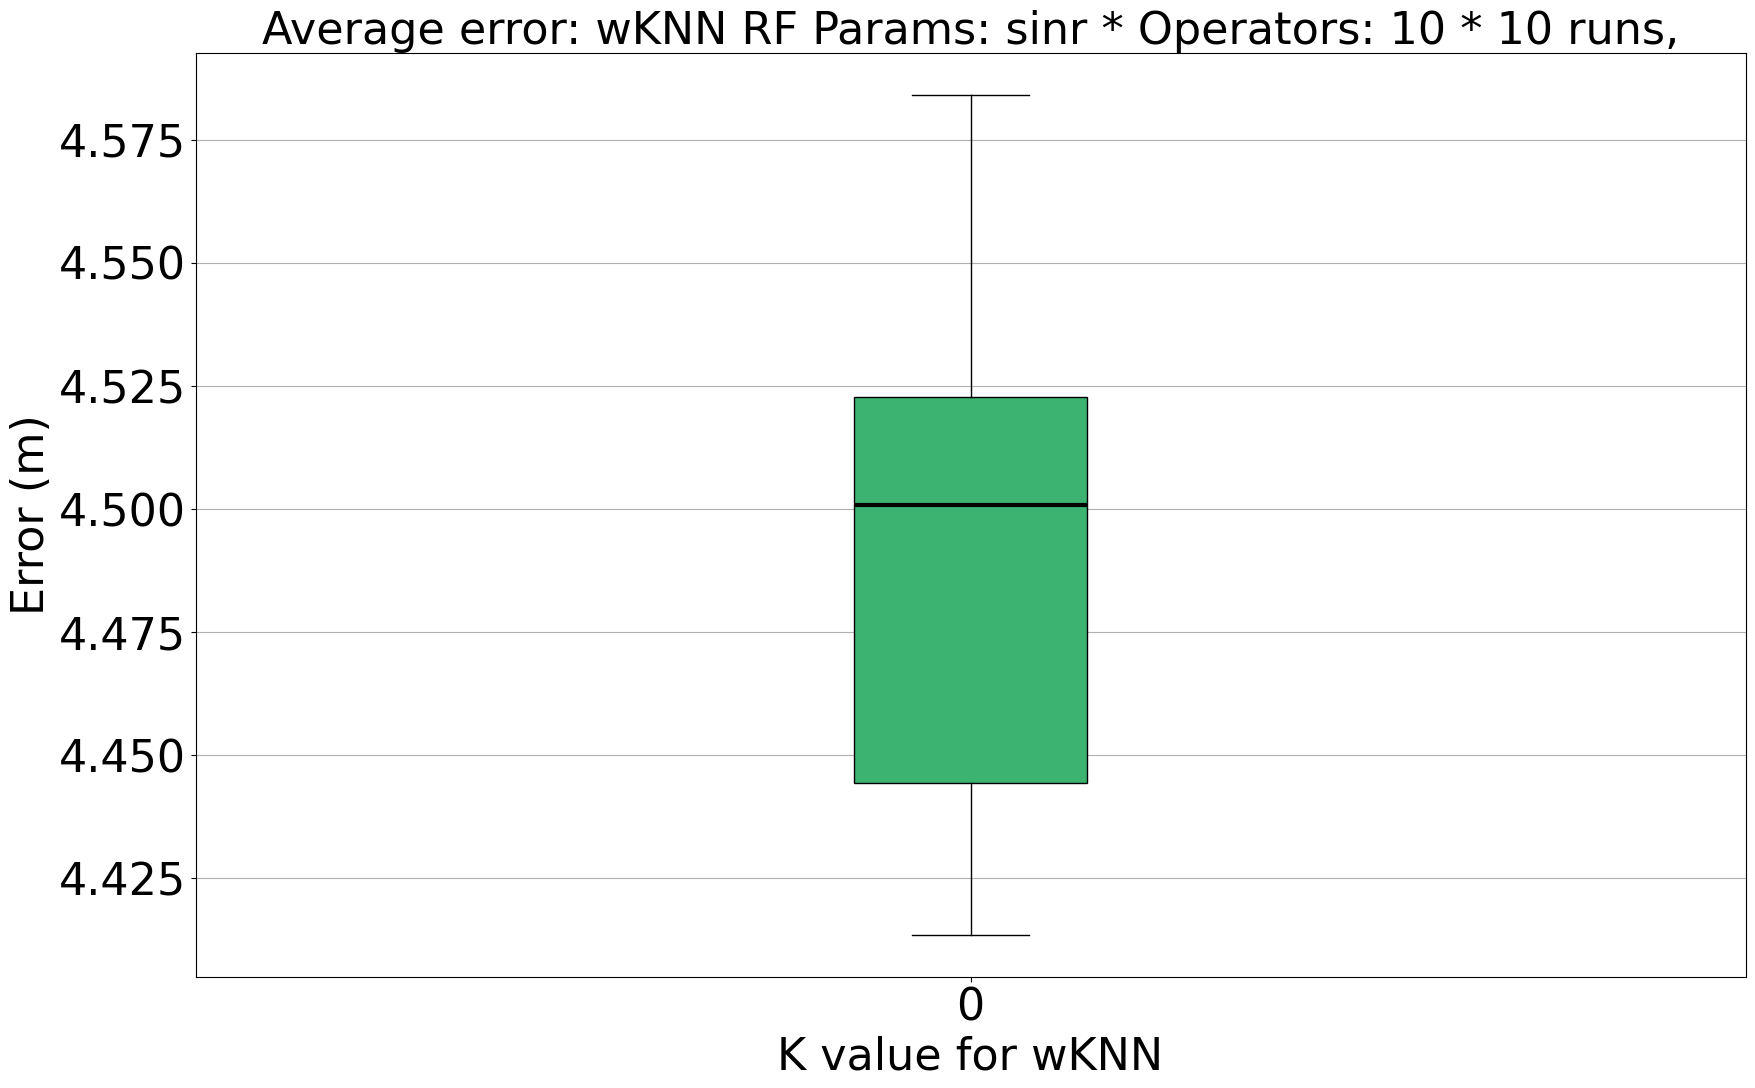

In [6]:
from scripts.utils import params_to_str, operators_to_str
from scripts.plotting import make_boxplot

# Plotting with capped runtime data
param_str = f'RF Params: {params_to_str(rf_params)}'
operator_str = f'Operators: {operators_to_str(operator_choice)}'

title_string = f"wKNN {param_str} * {operator_str} * {n_runs} runs,"

make_boxplot(
    df=errors_df,
    title=f'Average error: {title_string}',
    x_label='K value for wKNN',
    y_label='Error (m)',
    color='mediumseagreen',
)


In [7]:
errors_df.mean()

0    4.492412
dtype: float64